Unsupervised learning using scikit-learn to cluster penguins in antarctica using k-means methodology.

In [1]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [2]:
# Investigating the dataset size
penguins_df.shape

(332, 5)

In [3]:
# Performing preprocessing for the 'sex' column before applying the machine learning method, since it contains categorical data (using the get_dummies function)
penguins_preprocessed = pd.get_dummies(penguins_df, columns=['sex'], drop_first=True)
penguins_preprocessed.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,36.7,19.3,193.0,3450.0,False
4,39.3,20.6,190.0,3650.0,True


All columns are in numerical format so we can apply our ML methodology for clustering

In [4]:
# Performing standardization before clustering to increase the accuracy of the model. It makes the model features have mean 0 and variance of 1.
scaler= StandardScaler()
scaler.fit_transform(penguins_preprocessed)

array([[-0.90390586,  0.79035987, -1.42534179, -0.56694801,  0.99399394],
       [-0.83043377,  0.12618674, -1.0685765 , -0.50484747, -1.00604235],
       [-0.68348959,  0.43272819, -0.42639899, -1.18795343, -1.00604235],
       ...,
       [ 1.17168063, -0.74234736,  1.50013355,  1.91707363,  0.99399394],
       [ 0.21654349, -1.20215952,  0.78660298,  1.23396768, -1.00604235],
       [ 1.07984052, -0.53798639,  0.85795603,  1.48236985,  0.99399394]])

C:\Users\Hossein\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Hossein\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Hossein\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Hossein\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

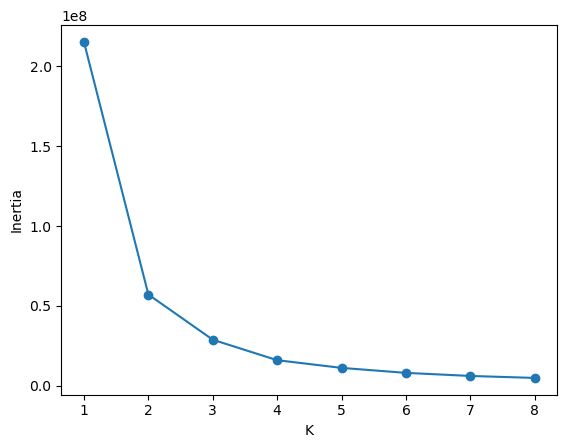

In [5]:
# Performing Elbow analysis to find the optimal value for inertia , and therefore, for the number of clusters (k)
ks= range(1,9)
inertia= []
for k in ks:
    model= KMeans(n_clusters=k)
    model.fit(penguins_preprocessed)
    inertia.append(model.inertia_)

# plotting the inertia values vs. k values for the Elbow analysis (finding the optimal choice for the number of clusters)
plt.plot(ks, inertia, '-o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.show()

The optimal k value based on the plot is 4 clusters

In [6]:
# Building the model and printing the inertia
model= KMeans(n_clusters=4)
model.fit_predict(penguins_preprocessed)

# Printing inertia of the model
print(model.inertia_)

15861290.889345264


C:\Users\Hossein\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:
# print model labels for dataset
model.labels_

array([1, 1, 3, 3, 1, 3, 0, 3, 1, 1, 3, 0, 3, 1, 3, 3, 1, 1, 1, 1, 3, 3,
       3, 1, 3, 1, 3, 1, 3, 1, 1, 3, 3, 0, 3, 1, 3, 0, 3, 0, 3, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 0, 3, 1, 3, 1, 3, 1, 3, 0, 3, 1, 3,
       1, 1, 1, 1, 1, 3, 1, 3, 0, 1, 1, 3, 3, 1, 3, 1, 3, 3, 1, 3, 0, 3,
       1, 1, 0, 3, 1, 1, 0, 3, 1, 3, 3, 1, 1, 3, 0, 1, 0, 3, 1, 1, 1, 3,
       1, 3, 3, 3, 3, 3, 1, 3, 1, 3, 1, 3, 1, 3, 3, 3, 0, 3, 1, 3, 1, 3,
       1, 3, 3, 3, 1, 3, 1, 1, 3, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1,
       1, 1, 1, 1, 1, 3, 1, 3, 1, 3, 0, 3, 3, 3, 1, 3, 1, 3, 1, 1, 0, 3,
       1, 3, 1, 3, 1, 1, 0, 3, 0, 1, 1, 3, 3, 1, 0, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 3, 3, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 0, 2, 0, 2, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 1, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 1, 0, 0, 2, 1, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,

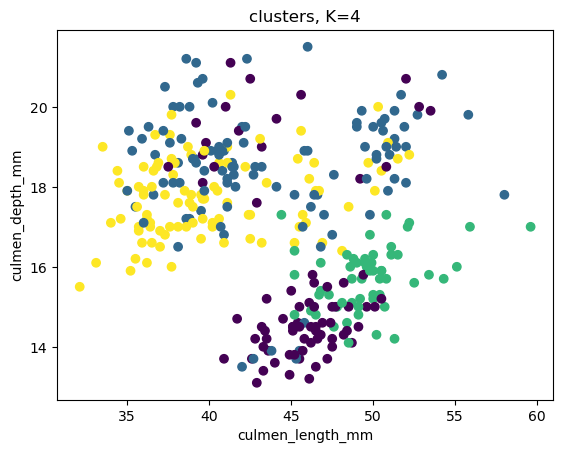

In [8]:
# Adding the cluster labels to the preprocessed data frame for visualization

# Create a copy to avoid changes to the original pre-processed data
df = penguins_preprocessed.copy()
# Adding a column named Labels
df['labels'] = model.labels_

# Visualizing the dataset using pyplot to better undestand the dataset
plt.scatter(df['culmen_length_mm'], df['culmen_depth_mm'], c=model.labels_)
plt.title('clusters, K=4')
plt.xlabel('culmen_length_mm')
plt.ylabel('culmen_depth_mm')
plt.show()

As can be seen in the scatter plot, there are 4 clusters, shown by 4 distinct colors.

Data manipulation and putting labels for the rows.

In [9]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE,labels
0,39.1,18.7,181.0,3750.0,True,1
1,39.5,17.4,186.0,3800.0,False,1
2,40.3,18.0,195.0,3250.0,False,3
3,36.7,19.3,193.0,3450.0,False,3
4,39.3,20.6,190.0,3650.0,True,1


In [10]:
# Selecting only the numeric columns of the original dataset (penguins_df)
numeric_columns = penguins_df.select_dtypes(include='number').columns.tolist()

In [11]:
print(numeric_columns)

['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [12]:
penguins_df["label"]= model.labels_
penguins_df.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex', 'label'],
      dtype='object')

In [13]:
# Create a DataFrame with cluster labels and the numeric columns from the original DataFrame
stat_penguins = penguins_df[numeric_columns + ['label']].copy()

# Group by the cluster label and calculate the mean of each numeric column for each cluster
stat_penguins.groupby('label').mean()


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,45.457895,15.661842,209.631579,4710.526316
1,43.570755,18.433962,195.141509,3936.320755
2,49.674545,15.725455,221.709091,5548.181818
3,40.101053,17.743158,188.557895,3327.894737


In [16]:
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,label
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,3
3,36.7,19.3,193.0,3450.0,3
4,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...
327,47.2,13.7,214.0,4925.0,0
328,46.8,14.3,215.0,4850.0,0
329,50.4,15.7,222.0,5750.0,2
330,45.2,14.8,212.0,5200.0,2
